In [4]:
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
file = "data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R1.csv"
df = pd.read_csv(file)

df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R1.csv'

In [6]:
import os 
os.getcwd()

'/Users/danyaleyva/Desktop/Project ECIS/notebooks'

In [7]:
os.listdir()

['ECIS_analysis.ipynb', '.ipynb_checkpoints']

In [9]:
import pandas as pd

file = "../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R1.csv"
df = pd.read_csv(file)

df.head()


,Time_min,Frequency_Hz,Impedance_Magnitude
0,0,500,862.929851
1,5,500,862.252284
2,10,500,873.224971
3,15,500,874.821405
4,20,500,865.888778


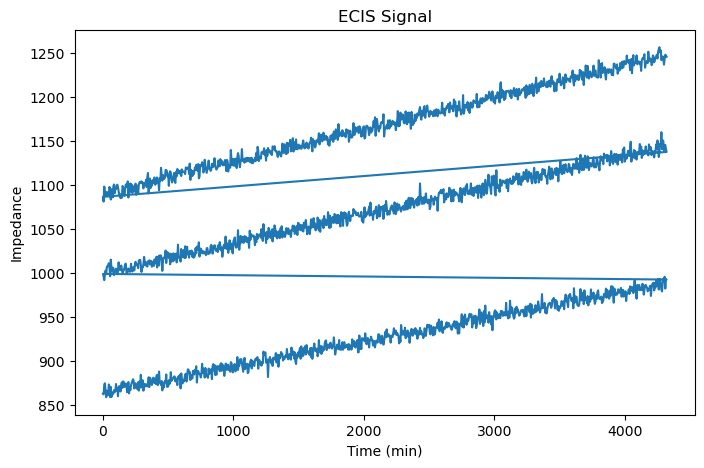

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(df["Time_min"], df["Impedance_Magnitude"])

plt.xlabel("Time (min)")
plt.ylabel("Impedance")
plt.title("ECIS Signal")

plt.show()

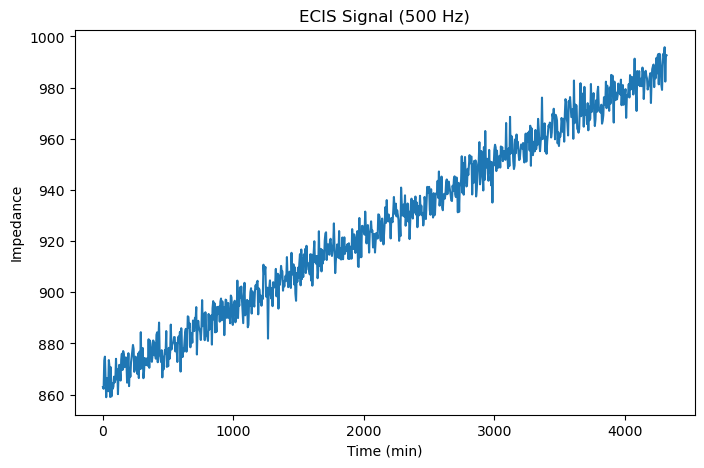

In [11]:
# multiple frequences are shows filter one out 
df_500 = df[df["Frequency_Hz"] == 500]

plt.figure(figsize=(8,5))
plt.plot(df_500["Time_min"], df_500["Impedance_Magnitude"])

plt.xlabel("Time (min)")
plt.ylabel("Impedance")
plt.title("ECIS Signal (500 Hz)")

plt.show() # SIGNAL SHOWS ONE FREQUENCY (500HZ) ONE CLEAN ECIS CURVE 
#STARTS AT ABOUT 865 GUADUALLY INCREASES TO ABOUT 995 SMALL NOISE FLUCTUATIONS

/var/folders/_7/szs_yvr964d2fg7v1x1w1gr00000gn/T/ipykernel_19872/2135158109.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline


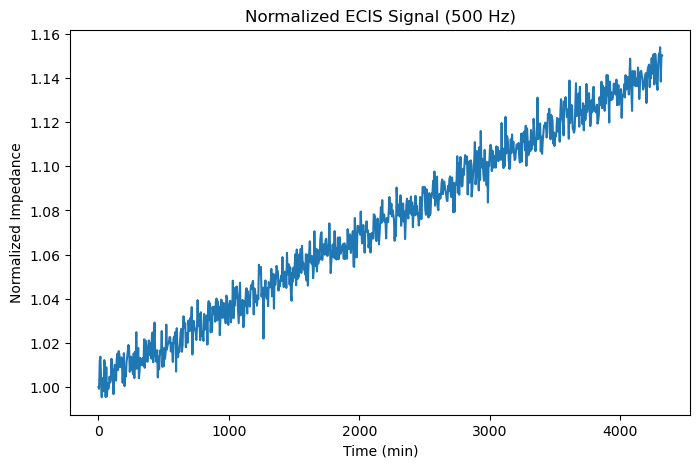

In [14]:
#NORMALIZATION 

baseline = df_500["Impedance_Magnitude"].iloc[0]
df_500["Normalized"] = df_500["Impedance_Magnitude"] / baseline

plt.figure(figsize=(8,5))
plt.plot(df_500["Time_min"], df_500["Normalized"])

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Normalized ECIS Signal (500 Hz)")

plt.show()

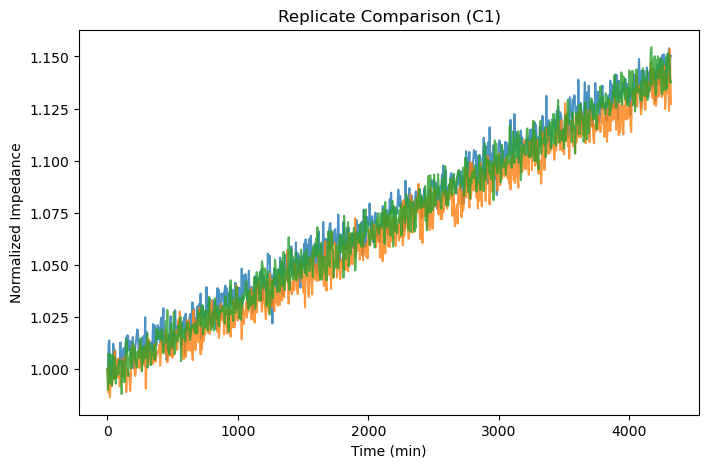

In [15]:
#replicating comparisons 
import pandas as pd
import matplotlib.pyplot as plt

files = [
    "../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R1.csv",
    "../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R2.csv",
    "../data/ecis_simulated_pilot (1)/pilot_sim_001_C1_R3.csv"
]

plt.figure(figsize=(8,5))

for file in files:
    df = pd.read_csv(file)
    df_500 = df[df["Frequency_Hz"] == 500].copy()
    
    baseline = df_500["Impedance_Magnitude"].iloc[0]
    norm = df_500["Impedance_Magnitude"] / baseline
    
    plt.plot(df_500["Time_min"], norm, alpha=0.8)

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Replicate Comparison (C1)")

plt.show()
# comparing R1. R2, R3 together 

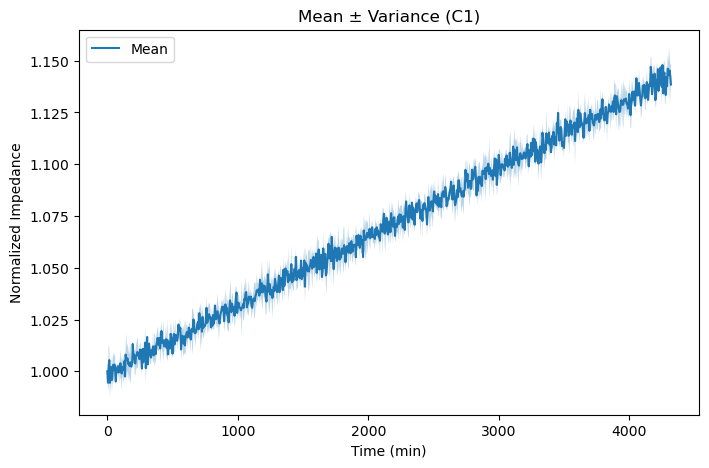

In [21]:
import numpy as np

replicates = []

for file in files:
    df = pd.read_csv(file)
    df_500 = df[df["Frequency_Hz"] == 500].copy()

    baseline = df_500["Impedance_Magnitude"].iloc[0]
    norm = df_500["Impedance_Magnitude"] / baseline

    replicates.append(norm.values)

replicates = np.array(replicates)

mean_signal = replicates.mean(axis=0)
std_signal = replicates.std(axis=0)

time = df_500["Time_min"]

plt.figure(figsize=(8,5))
plt.plot(time, mean_signal, label="Mean")

plt.fill_between(
    time,
    mean_signal - std_signal,
    mean_signal + std_signal,
    alpha=0.3
)

plt.xlabel("Time (min)")
plt.ylabel("Normalized Impedance")
plt.title("Mean ± Variance (C1)")
plt.legend()

plt.show()


## Pilot Analysis Notes

The pilot ECIS datasets were successfully loaded and processed in Python. Signals were filtered to a single frequency (500 Hz) and normalized to baseline impedance to allow comparison across wells.

Replicate comparison (R1–R3) showed consistent trends with relatively low variance, indicating stable cell seeding and reliable signal acquisition during the experiment.

The preprocessing pipeline is now functioning correctly, and the pilot data appear suitable for further analysis of experimental conditions.